# Downloading data from Monitor My Watershed using the TSV Endpoint

This notebook demonstrates how to use the Time Series Visualization (TSV) endpoint to extract data from Monitor My Watershed.
This endpoint serves as a temporary access point between the shut-down of the WoFpy service and the development of a more efficient and permanent service.

## Step 1: Import Libraries

We're just importing necessary libraries here.

In [17]:
# -*- coding: utf-8 -*-
# %% import libraries and library options
"""
Created on Thursday April 6, 2023

@author: Sara Geleskie Damiano

This script moves all data from series tagged with an Aquarius dataset primary
 key from a DreamHost database to Stroud's Aquarius server.
This uses command line arguments to decide what to append
"""

from typing import Union
import pytz
import pandas as pd
from datetime import datetime
import numpy as np
import requests
import json
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry
import logging

## Step 2: Set up logger

Nothing special, just setting up a logger

In [18]:
# %%
root = logging.getLogger()
root.setLevel(logging.INFO)
formatter = logging.Formatter(
    "%(asctime)s - %(levelname)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S"
)

## Step 3 Set up Monitor My Watershed Session

Here we set up a request session that will support by retries and timeouts.

In [19]:
# %%
# set up requests retry adapter
retry_strategy = Retry(
    total=10,
    status_forcelist=[413, 429, 500, 502, 503, 504],
    allowed_methods=["HEAD", "GET", "PUT", "DELETE", "OPTIONS", "TRACE", "POST"],
    backoff_factor=1,
)

# set up a timeout adapter
DEFAULT_TIMEOUT = 90  # seconds

#create a class that applies both the timeout and retry adapter together
class TimeoutHTTPAdapter(HTTPAdapter):
    def __init__(self, *args, **kwargs):
        self.timeout = DEFAULT_TIMEOUT
        if "timeout" in kwargs:
            self.timeout = kwargs["timeout"]
            del kwargs["timeout"]
        super().__init__(*args, **kwargs)

    def send(self, request, **kwargs):
        timeout = kwargs.get("timeout")
        if timeout is None:
            kwargs["timeout"] = self.timeout
        return super().send(request, **kwargs)


adapter = TimeoutHTTPAdapter(timeout=DEFAULT_TIMEOUT, max_retries=retry_strategy)
mmw_session = requests.Session()
mmw_session.mount("https://", adapter)
mmw_session.mount("http://", adapter)


## Step 4 Log in to Monitor My Watershed

Using the session we created, log in to Monitor My Watershed.
Make sure to replace `"YOUR_USERNAME"` and `"YOUR_PASSWORD"` with the appropriate values.

In [20]:
#%%
# log in to MonitorMW
logging.info("Logging in to MonitorMW")
login_url = "https://monitormywatershed.org/login/"
login_get_cookies = mmw_session.get(login_url).cookies
csfr_token = login_get_cookies["csrftoken"]
# http.cookies.set(name='csrftoken',value=csfr_token)
login_data = dict(
    username="YOUR_USERNAME",
    password="YOUR_PASSWORD",
    csrfmiddlewaretoken=csfr_token,
    next="/",
)
r = mmw_session.post(login_url, data=login_data, headers=dict(Referer=login_url))

mmw_session.headers.update(
    {
        "Referer": "https://monitormywatershed.org/tsv/",
        "Origin": "https://monitormywatershed.org",
    }
)


INFO:root:Logging in to MonitorMW


## Step 4:  A function to get Monitor My Watershed data

This function takes care of the two step process of getting data from the TSV endpoint of Monitor My Watershed.
Within the function, first the site code is used to extract metadata about the site, including the internal id corresponding to each variable code and UUID.
Then, using the internal id, we pull up the actual data.
After pulling in the data, we combine the millisescond timestamp and timezone into a pandas timezone-aware timestamp.
The final return is a panadas dataframe with the timestamp, data value, and utc offset.

In [21]:
# %%
def get_monitormw_data(
    site_code: str,
    *,
    uuid: Union[str, None] = None,
    variable_code: Union[str, None] = None,
    start_date: Union[pd.Timestamp, None] = None,
    end_date: Union[pd.Timestamp, None] = None,
) -> pd.DataFrame:
    """Fetches data from the Time Series Visualization endpoint for a specific site and variable and returns a pandas dataframe with the results.

    Args:
        site_code (str): The text site code
        uuid (str, optional): The 36 character UUID for the result; *including hyphens*.  Either the UUID *OR* the variable code should be specified, not both.  Defaults to None.
        variable_code (str, optional): The text variable code exactly as seen on MonitorMyWatershed.  Either the UUID *OR* the variable code should be specified, not both. Defaults to None.
        start_date (Timestamp, optional):  The first date to pull data from. If omitted, fetches from the beginning of available data.  **WARNING: fetching the full range of data may be very slow for time series with large amounts of data.**
        end_date (Timestamp, optional): The last date to pull data from. If omitted, fetches up to the most recent data available.  **WARNING: fetching the full range of data may be very slow for time series with large amounts of data.**

    Raises:
        ValueError: If no matching UUID or variable code can be found for the site.

    Returns:
        pd.DataFrame: The available data as a pandas data frame.
    """

    if uuid is None and variable_code is None:
        raise ValueError("Either UUID or variable code must be specified!")

    tsv_data_url = "https://monitormywatershed.org/dataloader/ajax/"

    logging.info(
        "Requesting MonitorMW metadata for {} at {}".format(
            site_code,
            pytz.utc.localize(datetime.utcnow())
            .astimezone(pytz.FixedOffset(-5 * 60))
            .isoformat(sep=" ", timespec="seconds"),
        )
    )
    tsv_result_id = None
    try:
        request_data = {
            "method": "get_sampling_feature_metadata",
            "sampling_feature_code": site_code,
        }
        request_data_str = json.dumps(request_data)
        payload = {"request_data": request_data_str}
        logging.debug(payload)

        tsv_site_req = mmw_session.post(tsv_data_url, data=payload)
        tsv_site_variables = json.loads(tsv_site_req.json())
        logging.debug(tsv_site_variables)
        for tsv_result in tsv_site_variables:
            if (uuid is not None and tsv_result["resultuuid"] == uuid) or (
                variable_code is not None
                and tsv_result["variablecode"] == variable_code
            ):
                tsv_result_id = tsv_result["resultid"]
                break
        if tsv_result_id is None:
            raise ValueError("No matching UUID or variable code found in site results!")

    except Exception as e:
        logging.warning("Error getting MMW data: {}".format(e))
        return pd.DataFrame(
            columns=[
                "timestamp",
                "datavalue",
                "valuedatetimeutcoffset",
            ]
        )

    logging.info(
        "Requesting MonitorMW data values for {} ({}, {}) at {} from {} to {} at {}".format(
            tsv_result_id,
            tsv_result["variablecode"],
            tsv_result["resultuuid"],
            tsv_result["samplingfeaturecode"],
            start_date.isoformat(sep=" ", timespec="seconds")
            if pd.notna(start_date)
            else "start of record",
            end_date.isoformat(sep=" ", timespec="seconds")
            if pd.notna(end_date)
            and end_date
            != pd.Timestamp(year=2025, month=1, day=1, tzinfo=pytz.FixedOffset(-5 * 60))
            else "end of record",
            pytz.utc.localize(datetime.utcnow())
            .astimezone(pytz.FixedOffset(-5 * 60))
            .isoformat(sep=" ", timespec="seconds"),
        )
    )

    data_online = None
    try:
        request_data = {
            "method": "get_result_timeseries",
            "resultid": "{}".format(tsv_result_id),
            "start_date": start_date.isoformat() if pd.notna(start_date) else None,
            "end_date": end_date.isoformat()
            if pd.notna(end_date)
            and end_date
            != pd.Timestamp(year=2025, month=1, day=1, tzinfo=pytz.FixedOffset(-5 * 60))
            else None,
        }
        request_data_str = json.dumps(request_data)
        payload = {"request_data": request_data_str}
        logging.debug(payload)

        data_tsv_result_req = mmw_session.post(tsv_data_url, data=payload)
        data_tsv_results = json.loads(data_tsv_result_req.json())
        data_online = pd.DataFrame.from_dict(data_tsv_results)

    except Exception as e:
        logging.warning("Error getting MMW data: {}".format(e))
        return pd.DataFrame(
            columns=["timestamp", "datavalue", "valuedatetimeutcoffset"]
        )

    # Convert the time column into a pandas datetime
    data_online["timestamp"] = pd.to_datetime(data_online["valuedatetime"], unit="ms")

    # apply timezone
    data_online["timestamp"] = data_online.groupby(
        "valuedatetimeutcoffset", dropna=False, sort=False
    )["timestamp"].transform(lambda x: x.dt.tz_localize(pytz.FixedOffset(x.name * 60)))

    if len(data_online.index) == 0:
        logging.info("   No data at all currently on MonitoryMyWatershed")
        return pd.DataFrame(
            columns=[
                "timestamp",
                "datavalue",
                "valuedatetimeutcoffset",
            ]
        )

    logging.info(
        "   {} points currently on MonitorMyWatershed between {} and {}".format(
            len(data_online.index),
            data_online["timestamp"].min().strftime("%m/%d/%Y"),
            data_online["timestamp"].max().strftime("%m/%d/%Y"),
        )
    )

    # sort by the timestamp
    data_online = data_online.sort_values(by=["timestamp"]).reset_index(drop=True)

    # infer the frequency from the most common (mode) spacing
    # NOTE: The pandas infer_freq function isn't up to the irregularities
    # in the spacing of the online data
    data_online["t_delta"] = (
        data_online["valuedatetime"] - data_online["valuedatetime"].shift(1)
    ) / 6e4
    data_online.loc[
        (data_online["t_delta"] < 0) | (data_online["t_delta"] > 1440), "t_delta"
    ] = np.nan
    # mean_freq = data_online['t_delta'].mean()
    # median_freq = data_online['t_delta'].median()
    mode_freq = data_online["t_delta"].mode().iloc[0]
    data_online["frequency"] = mode_freq

    return data_online.drop(columns=["t_delta"]).copy()


## Step 5:  Get some data

For this example, we'll get water specific conductance from site WCC017, which is a site adjacent to the Stroud Water Research Center's Avondale home.
The variable code for specific conductance from the Decagon CTD installed at this site is `Decagon_CTD-10_Cond`.
We could also have used the UUID for that variable.
Both the UUID and the variable code for every variable are displayed after clicking the "View Token UUID List" above the site picture for any station you own. 
The UUIDs for each variable will also display under then spark-line of any site you own.
You must be the owner of a site to view this information.
The function we created above requires that _either_ the variable code _or_ the UUID be given, not both.
In most cases, using the **_UUID_** should be preferred.

We should also specify the start and end time range over which we want to fetch data.
Collecting more than about a month of data is slow.
If we do not specify the start and end time, all data will be fetched which can be very, very slow.

In [22]:
site_code = "WCC017"
variable_code = "Decagon_CTD-10_Cond"
now = pytz.utc.localize(datetime.utcnow()).astimezone(pytz.FixedOffset(-5 * 60))
start_date = now - pd.Timedelta(value=30, unit="days")

data_online = get_monitormw_data(
    site_code=site_code,
    variable_code=variable_code,
    start_date=start_date,
    end_date=now,
)


INFO:root:Requesting MonitorMW metadata for WCC017 at 2023-04-06 10:39:50-05:00
INFO:root:Requesting MonitorMW data values for 567 (Decagon_CTD-10_Cond, 1a871325-565d-41b7-a0be-a5f13635ea8c) at WCC017 from 2023-03-07 10:39:50-05:00 to 2023-04-06 10:39:50-05:00 at 2023-04-06 10:39:51-05:00
INFO:root:   8355 points currently on MonitorMyWatershed between 03/07/2023 and 04/06/2023


Step 6: Plot the data

We'll plot up the data to make sure it looks reasonable.


<AxesSubplot: xlabel='timestamp'>

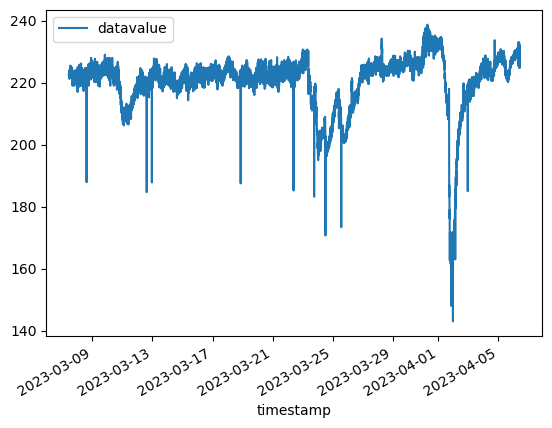

In [23]:
data_online.plot(x='timestamp',y='datavalue')